In [1]:
import os
import pickle
import yaml
import functools

import jax
import jax.numpy as jnp
import numpy as np
import matplotlib.pyplot as plt
from skimage import transform, feature

import ase
from ase.visualize.plot import plot_atoms

import ml_collections
from clu import checkpoint

from molnet import utils, train_state, train
from molnet.data import input_pipeline_fdbm
from molnet.models import create_model
from configs import root_dirs
from analyses import make_predictions

from typing import Tuple

INDEX_TO_SYMBOL = {
    0: 'background',
    1: 'H', 2: '(He)',
    3: '(Li)', 4: '(Be)', 5: '(B)', 6: 'C', 7: 'N', 8: 'O', 9: 'F', 10: 'Ne',
    11: 'Na', 12: 'Mg', 13: 'Al', 14: 'Si', 15: 'P', 16: 'S', 17: 'Cl', 18: 'Ar',
    19: 'K', 20: 'Ca', 21: 'Sc', 22: 'Ti', 23: 'V', 24: 'Cr', 25: 'Mn', 26: 'Fe', 27: 'Co', 28: 'Ni', 29: 'Cu', 30: 'Zn', 31: 'Ga', 32: 'Ge', 33: 'As', 34: 'Se', 35: 'Br',
}
INDEX_TO_SYMBOL_SHORT = {
    0: "background",
    1: "H", 2: "C", 3: "N", 4: "O", 5: "F",
    6: "Si", 7: "P", 8: "S", 9: "Cl", 10: "Br",
}

2025-03-04 12:14:03.211791: W tensorflow/compiler/tf2tensorrt/utils/py_utils.cc:38] TF-TRT Warning: Could not find TensorRT


In [19]:
from PIL import Image

def interpolate_and_crop(
    x: np.ndarray, real_dim: Tuple[int, int], target_res: float = 0.125, target_multiple: int = 8
) -> list[np.ndarray]:
    """
    Interpolate a batch of AFM images to target resolution and crop to a target multiple of pixels in the xy plane.

    Arguments:
        x: AFM images to interpolate and crop. Each array should be of shape ``(batch_size, x, y, z)``.
        real_dim: Real-space size of AFM image region in x- and y-directions in Ångstroms.
        target_res: Target size for a pixel in angstroms.
        target_multiple: Target multiple of pixels of output image.

    Returns:
        Interpolated and cropped AFM images.
    """

    resized_shape = (int(real_dim[1] // target_res), int(real_dim[0] // target_res))
    # Interpolate for correct resolution
    Xs_ = np.empty((x.shape[0], resized_shape[1], resized_shape[0], x.shape[-1]))
    for i in range(x.shape[0]):
        for j in range(x.shape[-1]):
            Xs_[i, :, :, j] = np.array(Image.fromarray(x[i, :, :, j]).resize(resized_shape, Image.BILINEAR))

    # Crop for correct multiple of pixels
    dx = resized_shape[1] % target_multiple
    x_start = int(np.floor(dx / 2))
    x_end = resized_shape[1] - int(np.ceil(dx / 2))

    dy = resized_shape[0] % target_multiple
    y_start = int(np.floor(dy / 2))
    y_end = resized_shape[0] - int(np.ceil(dy / 2))

    return Xs_[:, x_start:x_end, y_start:y_end]


def normalize(
    Xs: np.ndarray,
) -> list[np.ndarray]:
    """
    Normalize a batch of AFM images.

    Arguments:
        X: AFM images to normalize. should be of shape ``(batch_size, x, y, z)``.
    Returns:
        Normalized AFM images.
    """

    xmean = np.mean(Xs, axis=(1, 2), keepdims=True)
    xstd = np.std(Xs, axis=(1, 2), keepdims=True)

    return (Xs - xmean) / (xstd + 1e-9)

In [3]:
def load_from_workdir(
    workdir: str,
    return_attention: bool
):
    # Load the model config
    with open(os.path.join(workdir, "config.yaml"), "rt") as f:
        config = yaml.unsafe_load(f)
    config = ml_collections.ConfigDict(config)
    config.root_dir = root_dirs.get_root_dir("afms_rebias")
    config.model.return_attention_maps = return_attention

    print(config)

    # Create the model
    model = create_model(config.model)

    checkpoint_dir = os.path.join(workdir, "checkpoints")
    ckpt = checkpoint.Checkpoint(checkpoint_dir)

    apply_fn = model.apply
    tx = utils.create_optimizer(config)
    restored_state = ckpt.restore(state=None)['state']

    # Load the model state
    state = train_state.EvaluationState.create(
        apply_fn=apply_fn,
        params=restored_state['params'],
        batch_stats=restored_state['batch_stats'],
        tx=tx,
    )
    state = jax.tree_util.tree_map(jnp.asarray, state)

    return state, config


In [4]:
@jax.jit
def predict(state, x):
    preds = state.apply_fn(
        {'params': state.params, 'batch_stats': state.batch_stats},
        x,
        training=False,
    )
    return preds

In [5]:
workdir = "/u/79/kurkil1/unix/work/molnet/runs/segmentation/segment-fdbm-adam-3e-4-ce/"

state, config = load_from_workdir(
    workdir=workdir,
    return_attention=False
)

batch_size: 12
cutout_probs:
- 0.5
- 0.3
- 0.1
- 0.05
- 0.05
dataset: SIN-AFM-FDBM-tf
debug: false
eval_every_steps: 2000
gaussian_factor: 1.0
interpolate_input_z: null
learning_rate: 0.0003
learning_rate_schedule: constant
learning_rate_schedule_kwargs:
  decay_steps: 50000
  init_value: 0.0003
  peak_value: 0.0006
  warmup_steps: 2000
log_every_steps: 100
loss_fn: cross_entropy
max_atoms: 54
max_shift_per_slice: 0.02
model:
  attention_activation: sigmoid
  attention_channels:
  - 16
  - 32
  - 64
  - 64
  - 128
  conv_activation: relu
  decoder_channels:
  - 256
  - 128
  - 64
  - 32
  - 16
  decoder_kernel_size:
  - - 3
    - 3
    - 3
  - - 3
    - 3
    - 3
  - - 3
    - 3
    - 3
  - - 3
    - 3
    - 3
  - - 3
    - 3
    - 3
  dtype: bfloat16
  encoder_channels:
  - 16
  - 32
  - 64
  - 128
  - 256
  encoder_kernel_size:
  - - 3
    - 3
    - 3
  - - 3
    - 3
    - 3
  - - 3
    - 3
    - 3
  - - 3
    - 3
    - 3
  - - 3
    - 3
    - 3
  model_name: Attention-UNet
  output_

2025-03-04 12:14:22.843906: W tensorflow/core/common_runtime/gpu/gpu_device.cc:1960] Cannot dlopen some GPU libraries. Please make sure the missing libraries mentioned above are installed properly if you would like to use GPU. Follow the guide at https://www.tensorflow.org/install/gpu for how to download and setup the required libraries for your platform.
Skipping registering GPU devices...


In [6]:
root_dir = '/l/exp_data/'
exclude_dirs = ["Nitrophenyls"]
datasets = [
    os.path.join(root_dir, folder) 
    for folder in os.listdir(root_dir)
    if os.path.isdir(os.path.join(root_dir, folder))
]
print(datasets)

# Create datasets directory, where the key is the dataset name and the value is all the files in the dataset.
datasets = {
    dataset.split("/")[-1]: [os.path.join(dataset, file) for file in os.listdir(dataset) if "Xe" not in file]
    for dataset in datasets
    if dataset.split("/")[-1] not in exclude_dirs
}

['/l/exp_data/Br-Cl-I-Benzene', '/l/exp_data/Xylotetraose', '/l/exp_data/22Bipyrimidine', '/l/exp_data/BCB', '/l/exp_data/Water', '/l/exp_data/PTCDA', '/l/exp_data/DBBA', '/l/exp_data/1S-Camphor', '/l/exp_data/Me-PTCDI', '/l/exp_data/Xe-cluster', '/l/exp_data/Nitrophenyls']


In [44]:
#d = datasets['Br-Cl-I-Benzene'][0]
d = datasets["1S-Camphor"][0]
data = np.load(d, allow_pickle=True)
x, lx, ly = data['data'], data['lengthX'], data['lengthY']
x = x[None, ...]

#xs = []
# Get all z=10 slices
#for i in range(x.shape[-1]-10):
#    xs.append(x[:, :, :, i:i+10])
#xs = np.concatenate(xs, axis=0)

xs = x
xs = interpolate_and_crop(xs, (lx, ly), target_res=0.125, target_multiple=32)
xs = normalize(xs)

#for x in xs:
#    fig = plt.figure(figsize=(15, 2))
#    for i in range(x.shape[-1]):
#        ax = plt.subplot(1, x.shape[-1], i+1)
#        im = ax.imshow(x[..., i])
#        plt.colorbar(im)
#        ax.axis('off')

xs = xs[..., None]

In [45]:
print(xs.shape)
y = predict(state, xs)
print(y.shape)

(1, 128, 128, 10, 1)
(1, 128, 128, 10, 36)


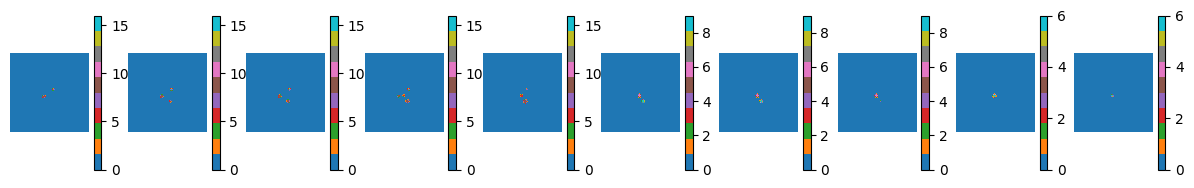

In [46]:
for i in range(y.shape[0]):
    ypred = y[i].argmax(axis=-1)
    fig = plt.figure(figsize=(15, 2))
    for j in range(ypred.shape[-1]):
        ax = plt.subplot(1, ypred.shape[-1], j+1)
        im = ax.imshow(ypred[..., j], cmap='tab10')
        plt.colorbar(im)
        ax.axis('off')

(512, 512, 13) 13.5 13.5
(96, 96, 10)


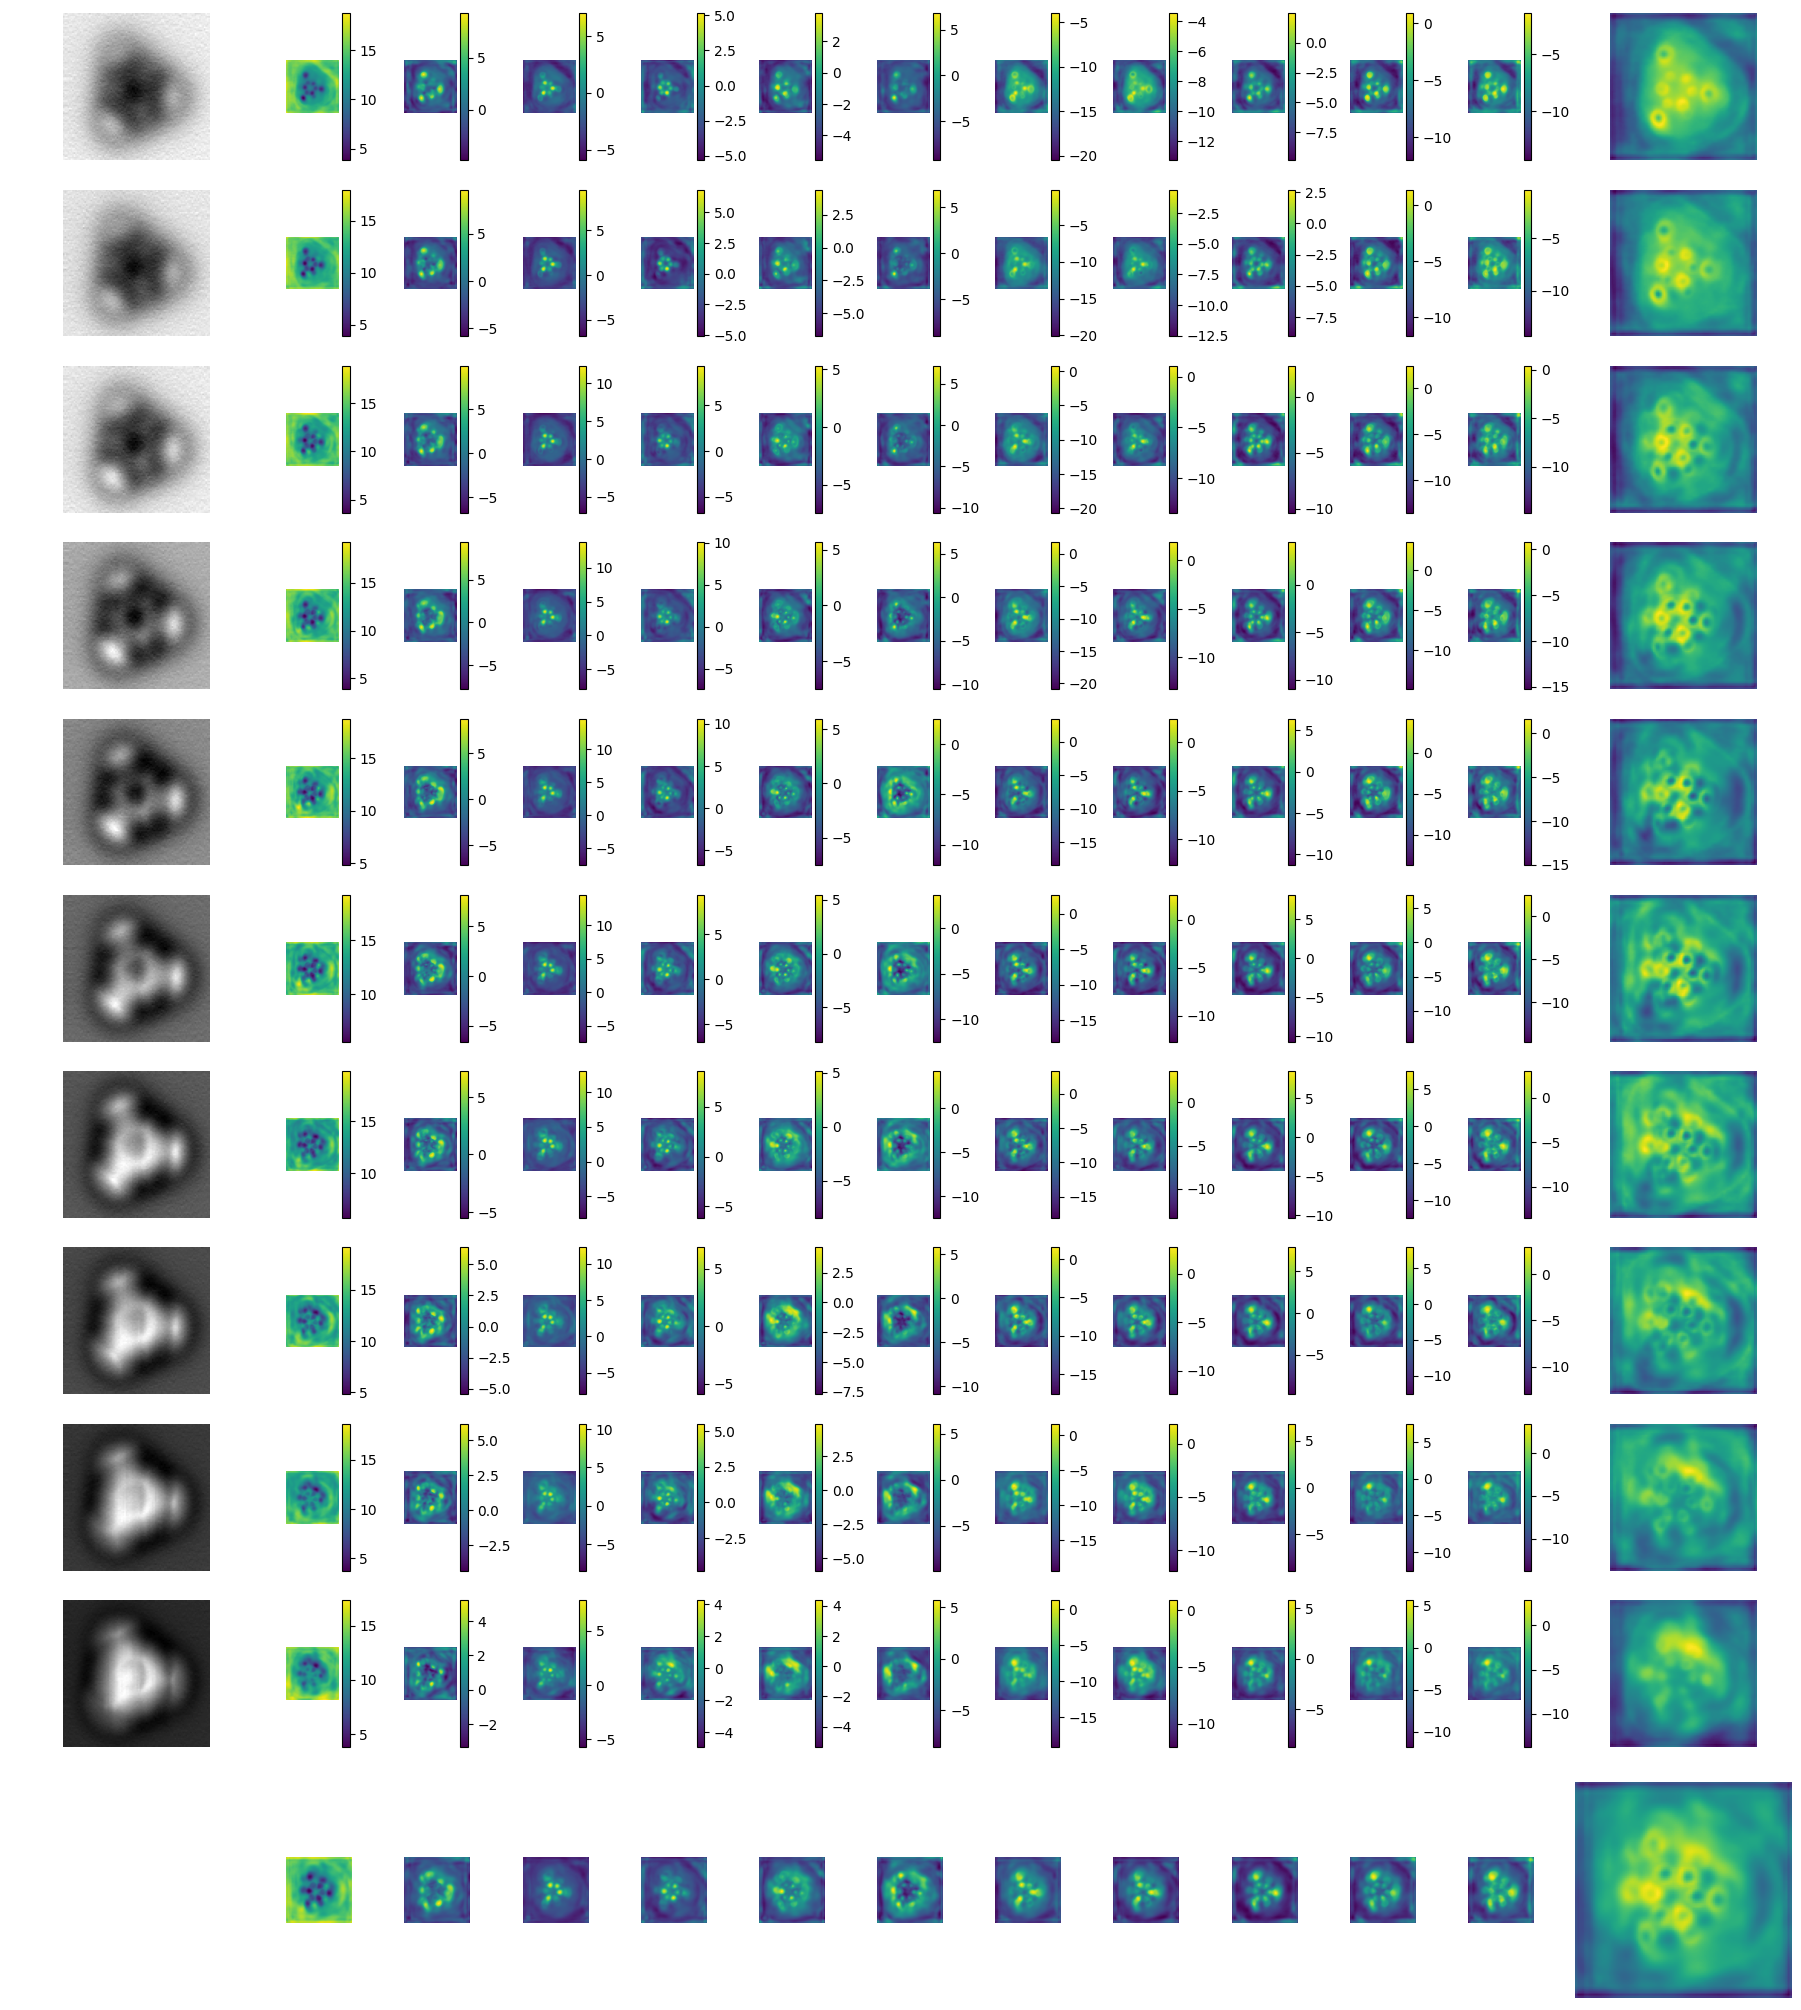

In [43]:
# 2. Plot the full prediction [1, x, y, z, element]
nrows = 10
ncols = 9
fig = plt.figure(figsize=(ncols * 2, nrows * 2))
subfigs = fig.subfigures(2, 3, height_ratios=[8, 1], width_ratios=[1, 5, 1], wspace=0.02, hspace=0.02)

#d = datasets['Br-Cl-I-Benzene'][0]
d = datasets["BCB"][0]
data = np.load(d, allow_pickle=True)

x, lx, ly = data["data"], data["lengthX"], data["lengthY"]
print(x.shape, lx, ly)
x = jnp.array(x)

x = x[..., -10:]
x = (x - x.mean()) / x.std()

# Current ångström / pixel ratio is lx / x.shape[0]
# Resize to 0.125 Å / pixel
new_size = (int(lx / 0.125), int(ly / 0.125))
x = transform.resize(x, new_size, mode='reflect', anti_aliasing=True)

# Crop x.shape[0] to the closest smaller multiple of 32
x = x[:x.shape[0] - x.shape[0] % 32, :x.shape[1] - x.shape[1] % 32]
print(x.shape)

x = x[None, ..., None]
y = predict(state, x)

# Plot the input in subfigs[0, 0]
ax = subfigs[0, 0].subplots(10,1)
for i in range(10):
    ax[i].imshow(x[0, ..., i, 0], cmap='gray')
    ax[i].axis('off')

species = [0, 1, 6, 7, 8, 9, 14, 15, 16, 17, 35]
# Plot the output in subfigs[0, 1]
ax = subfigs[0, 1].subplots(10, len(species))
for i in range(10):
    for j, z in enumerate(species):
        im = ax[i, j].imshow(y[0, ..., i, z], cmap='viridis')
        ax[i, j].axis('off')
        plt.colorbar(im, ax=ax[i, j])

# Plot the sum of the output in subfigs[0, 2]
ax = subfigs[0, 2].subplots(10, 1)
for i in range(10):
    ax[i].imshow(y[0, ..., i, :].sum(axis=-1), cmap='viridis')
    ax[i].axis('off')

# Plot the sum of the output in subfigs[1, 1]
ax = subfigs[1, 1].subplots(1, len(species))
for i, z in enumerate(species):
    ax[i].imshow(y[0, ..., :, z].sum(axis=-1), cmap='viridis')
    ax[i].axis('off')

# Plot the total sum in subfigs[1, 2]
ax = subfigs[1, 2].subplots(1, 1)
ax.imshow(y[0].sum(axis=(-1, -2)), cmap='viridis')
ax.axis('off')

plt.tight_layout()